In [1]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 31.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:

from roboflow import Roboflow
rf = Roboflow(api_key="z07DdG14GLd1gbxDiR4o")
project = rf.workspace("aatifpathancv").project("clothes-detection-es9pt")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Clothes-detection-3 in yolov8:: 100%|██████████| 1400/1400 [00:00<00:00, 3845.53it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import torch
from ultralytics import YOLO
import cv2 as cv
import matplotlib.pyplot as plt



device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


 ### Code Structure:  
 1. *(class)* -> Pretrained model selection: s,n,m,l,x <- *(arg)*
 2. data loading: path of the dataset <- *(arg)*
 3. *(train function)* -> training the model: training args/config. <- *(arg)*
 4. *(eval function)* -> performance on val data
 5. *(show results function)* -> shows the training matrices
 6. *(detect function)* -> detect in new image

In [10]:
class CustomYOLOTrainer:
  """ Train YOLO model on custom dataset """

  def __init__(self, data_yaml, model_size='n'):
    """
    Initialize trainer with dataset and model size.

    Args:
      data_yml (str): Path to the dataset YAML file.
      model_size (str): 'n', 's','m','l','x'
    """

    self.data_yaml = data_yaml
    self.model = YOLO(f'yolov8{model_size}.pt') # load pretrained YOLO model
    self.results = None


  def train(self,epochs = 50, time=None, patience =10, batch=16,imgsz = 640, save_period =-1, device='cpu'):
    """
    Args:
      epochs = number of training iterations.
      time = time in hours for which to train.
      patience = waiting for max epochs with no improvement in val loss.
      batch = batch of images to feed.
      imgsz = input image size for yolo model.
      save_periods = number of epochs duration after which to save checkpoints.
      device = device on which to run the training.
    """


    config = {
        'data': self.data_yaml,
        'epochs': epochs,
        'time': time,
        'patience': patience,
        'batch': batch,
        'imgsz': imgsz,
        'save_period': save_period,
        'device': device
    }

    print("\n"+"="*60)
    print(f"🚀 Starting the training...")
    print("="*60)

    self.results = self.model.train(**config)

    print("\n"+"="*60)
    print(f"✅ Training completed !")
    print("="*60)


    return self.results

def evaluation(self):
  """
  Provide model performance on val data
  """
  print(f"\n Evaluating Model... ")

  metrics = self.model.val()

  print('Evaluation completed !')
  print('='*60)
  print('Validation results')
  print('='*60)

  print(f"mAP50: {metrics.box.map50:.4f}")        # mAP at IoU=0.50
  print(f"mAP50-95: {metrics.box.map:.4f}")       # mAP at IoU=0.50:0.95
  print(f"Precision: {metrics.box.mp:.4f}")       # Mean precision
  print(f"Recall: {metrics.box.mr:.4f}")          # Mean recall
  return metrics


#def show_train_resuls(self):

def detect(self,img_path):
  detection = self.model(img_path)
  img = detection[0].plot()
  r_img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
  plt.imshow(r_img)
  plt.axes('off')
  plt.show()





In [13]:
ClothDetector = CustomYOLOTrainer(data_yaml='/content/Clothes-detection-3/data.yaml', model_size = 'm')

In [14]:
results = ClothDetector.train(save_period=10, device = device)


🚀 Starting the training...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Clothes-detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [17]:
import pandas as pd

In [20]:
def show_train_resuls(result_path):
  df = pd.read_csv(str(result_path)+'/results.csv')

# Plot training curves
  fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
  axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
  axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
  axes[0, 0].set_title('Training Losses')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].legend()

# mAP curves
  axes[0, 1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
  axes[0, 1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
  axes[0, 1].set_title('Validation mAP')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].legend()

# Precision & Recall
  axes[1, 0].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
  axes[1, 0].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
  axes[1, 0].set_title('Precision & Recall')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].legend()

# F1 Score
  f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / \
      (df['metrics/precision(B)'] + df['metrics/recall(B)'])
  axes[1, 1].plot(df['epoch'], f1, label='F1 Score')
  axes[1, 1].set_title('F1 Score')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].legend()

  plt.tight_layout()
  plt.savefig('training_analysis.png', dpi=150)
  plt.show()



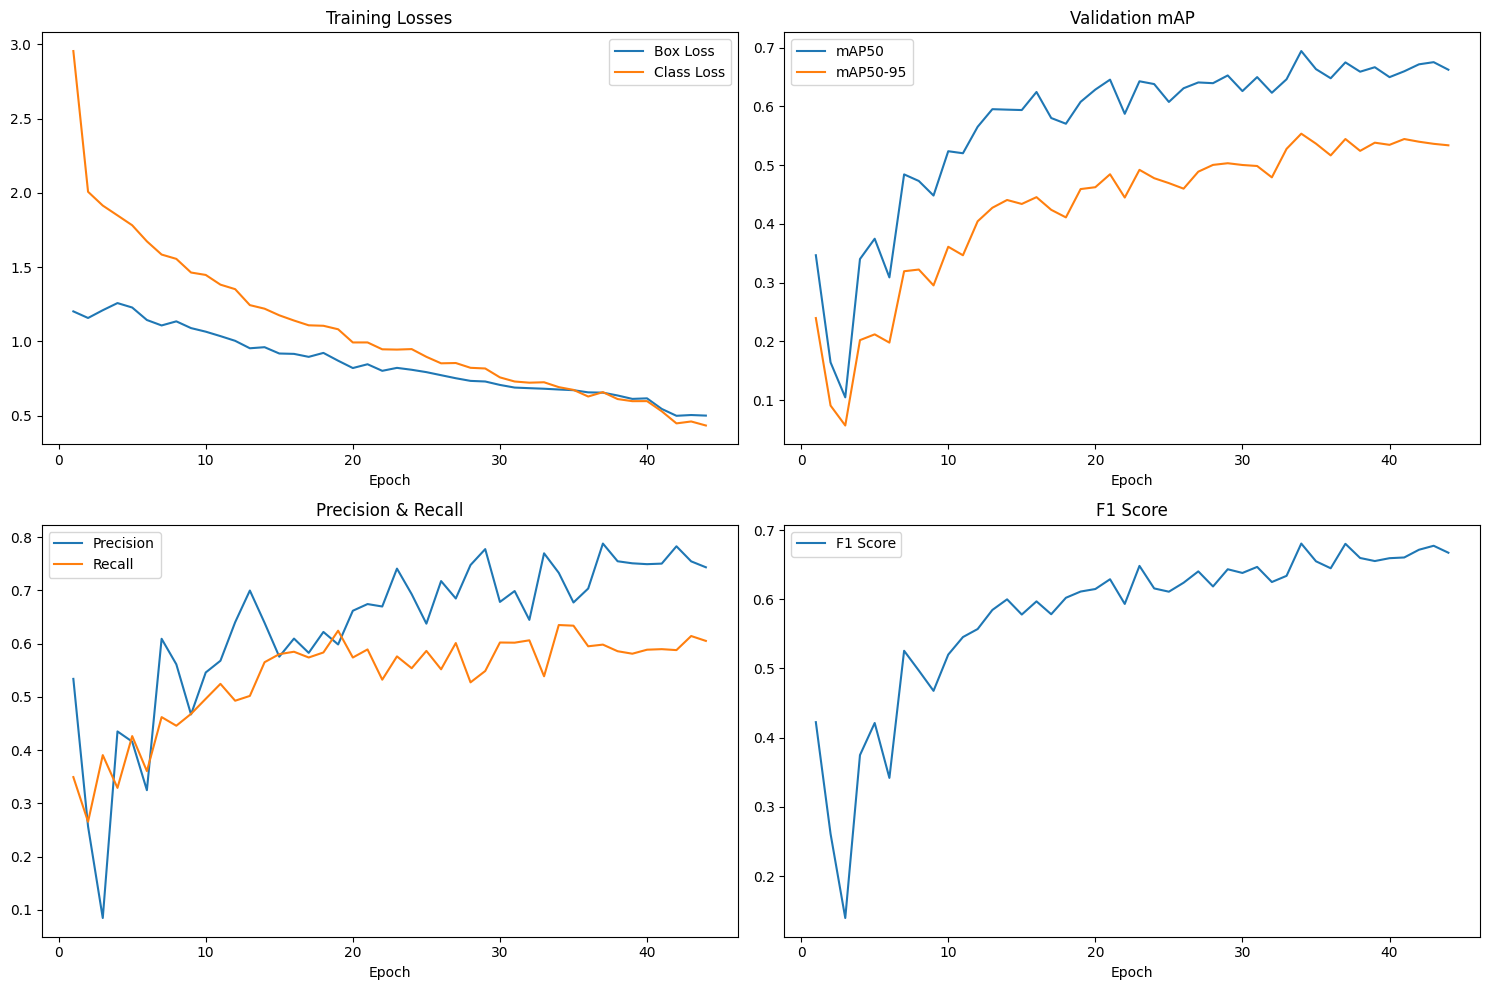

In [21]:
show_train_resuls(results.save_dir)